In [23]:
import warnings
warnings.filterwarnings("ignore")        # suppress noisy convergence warnings

import os
import joblib                            # to save/load trained model objects
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sklearn: splitting & evaluation ---
from sklearn.model_selection import (
    StratifiedKFold,          # 5-fold CV that keeps class ratios balanced
    cross_validate,           # runs CV and returns multiple score metrics
    GridSearchCV,             # exhaustive hyperparameter search
)

# --- Sklearn: preprocessing ---
from sklearn.preprocessing import (
    LabelEncoder,             # converts class names  →  integers
    StandardScaler,           # rescales features to mean=0, std=1
    OrdinalEncoder,           # encodes text categories  →  numeric codes
    label_binarize,
)
from sklearn.impute import SimpleImputer  # fills missing values

# --- Sklearn: pipeline & column routing ---
from sklearn.pipeline  import Pipeline          # chains steps sequentially
from sklearn.compose   import ColumnTransformer # routes columns to different steps

# --- Sklearn: feature selection ---
from sklearn.feature_selection import (
    VarianceThreshold,        # drops near-constant / zero-variance features
    SelectKBest,              # keeps top-k features by a scoring function
    f_classif,                # ANOVA F-score: measures class separability per feature
)

# --- Sklearn: classifiers ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble     import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,  # XGBoost alternative — built into sklearn,
                                     # zero extra install needed, handles missing
                                     # values natively, same boosting power
)
from sklearn.svm import SVC

from xgboost import XGBClassifier

# --- Sklearn: metrics
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    roc_auc_score,
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df_train = pd.read_csv(r"E:\first_iterations\checkin-2\xgboost + others\train_66_ros_modified.csv")

# #rename disease column
# df_train = df_train.rename(columns={"disease_y": "disease"})
# df_train.to_csv(r"E:\first_iterations\pahul\train_66_ros_modified.csv", index=False)

# print(f"  Rows    : {df_train.shape[0]}")
# print(f"  Columns : {df_train.shape[1]}")
# print(f"\n  Class distribution (disease):")
# print(df_train["disease"].value_counts().to_string())
# print()

# print(df_train["disease"].unique())

In [25]:
# TARGET = "disease"

X_train_raw = df_train.drop(columns=["disease"]).copy()
y_train = df_train["disease"].copy()

print(f"  Feature matrix shape  : {X_train_raw.shape}")
print(f"  Target series shape   : {y_train.shape}")
print()

  Feature matrix shape  : (10940, 72)
  Target series shape   : (10940,)



In [26]:
print("=" * 65)
print("STEP 4 : Identifying column types")
print("=" * 65)

bool_cols = X_train_raw.select_dtypes(include="bool").columns.tolist()
cat_cols  = X_train_raw.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols  = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()

print(f"  Boolean columns     : {bool_cols}")
print(f"  Categorical columns : {cat_cols}")
print(f"  Numeric columns     : {len(num_cols)} columns")
print(f"\n  Missing value counts:")
missing = X_train_raw.isnull().sum()
print(missing[missing > 0].to_string())
print()

""" it may have been because of the NaNs  """

STEP 4 : Identifying column types
  Boolean columns     : ['cough_present', 'fever_present']
  Categorical columns : ['gender', 'smoker', 'cold_present']
  Numeric columns     : 67 columns

  Missing value counts:
smoker          3530
cold_present    1605



' it may have been because of the NaNs  '

In [27]:
# =============================================================================
# STEP 5 — FIX BOOLEAN COLUMNS
# =============================================================================
# sklearn models internally treat all data as floats.
# Python booleans (True/False) need to be converted to 1.0 / 0.0 explicitly,
# otherwise some transformers may throw dtype errors.

print("=" * 65)
print("STEP 5 : Converting boolean columns to float (True→1.0, False→0.0)")
print("=" * 65)

X_train_raw[bool_cols] = X_train_raw[bool_cols].astype(float)

# After conversion, add them into num_cols so they get scaled alongside numbers
for col in bool_cols:
    if col not in num_cols:
        num_cols.append(col)

print(f"  Converted : {bool_cols}")
print(f"  Updated numeric column count : {len(num_cols)}")
print()

STEP 5 : Converting boolean columns to float (True→1.0, False→0.0)
  Converted : ['cough_present', 'fever_present']
  Updated numeric column count : 69



In [28]:
# =============================================================================
# STEP 6 — ENCODE THE TARGET LABELS
# =============================================================================
# LabelEncoder converts string class names to integers:
#   healthy → 0,  asthma → 1,  copd → 2,  covid → 3   (alphabetical)
# Several sklearn models work better with integer targets. The mapping is
# saved so we can decode predictions back to human-readable names later.

print("=" * 65)
print("STEP 6 : Encoding target labels to integers")
print("=" * 65)

y_train = y_train.map({
    "healthy": 0,
    "asthma": 1,
    "copd": 2,
    "covid": 3
})

print(y_train.unique())

STEP 6 : Encoding target labels to integers
[1 3 0 2]


In [29]:
# STEP 7 — BUILD THE PREPROCESSING PIPELINE
# =============================================================================
# We build two sub-pipelines:
#
#   num_transformer  → for all numeric + boolean columns
#     1. SimpleImputer(median)  : fills NaN with the column median value
#                                 (median is robust to outliers unlike mean)
#     2. StandardScaler         : rescales each feature to mean=0, std=1
#                                 (essential for SVM and Logistic Regression)
#
#   cat_transformer  → for categorical text columns (just "gender" here)
#     1. SimpleImputer(most_frequent) : fills NaN with the most common value
#     2. OrdinalEncoder               : encodes "female"/"male" → 0.0 / 1.0
#
#   ColumnTransformer forks the data, applies each transformer to its
#   designated columns, and reassembles everything into one matrix.

print("=" * 65)
print("STEP 7 : Building the preprocessing pipeline")
print("=" * 65)

# --- numeric sub-pipeline ---
num_transformer = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="median"),
        # WHY median: 'smoker' and 'cold_present' are binary (0/1) columns
        # with ~32% and ~15% missing. Median preserves the 0/1 nature better
        # than mean (which would give a decimal like 0.22).
    ),
    (
        "scaler",
        StandardScaler(),
        # WHY scale: MFCC features span wildly different ranges
        # (mfcc_1_mean ~ -192, zcr_mean ~ 0.001). Without scaling, features
        # with large values dominate distance-based models like SVM.
    ),
])

# --- categorical sub-pipeline ---
cat_transformer = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="most_frequent"),
    ),
    (
        "encoder",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            # handle_unknown: if a new unseen category appears at inference
            # time, encode it as -1 instead of crashing.
        ),
    ),
])

# --- combine both into one ColumnTransformer ---
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols),
    ],
    remainder="drop",   # drop any leftover columns (there shouldn't be any)
)

print("  num_transformer  → impute (median) + StandardScaler")
print(f"    applies to {len(num_cols)} numeric/bool columns")
print("  cat_transformer  → impute (most_frequent) + OrdinalEncoder")
print(f"    applies to {len(cat_cols)} categorical columns : {cat_cols}")
print()

STEP 7 : Building the preprocessing pipeline
  num_transformer  → impute (median) + StandardScaler
    applies to 69 numeric/bool columns
  cat_transformer  → impute (most_frequent) + OrdinalEncoder
    applies to 3 categorical columns : ['gender', 'smoker', 'cold_present']



In [30]:
# =============================================================================
# STEP 8 — BUILD THE FEATURE SELECTION PIPELINE
# =============================================================================
# Even after preprocessing, we have 72 features — many of which are correlated
# MFCC variants.  Keeping all of them risks:
#   • overfitting (model memorises noise instead of signal)
#   • slower training
#   • reduced interpretability
#
# We apply two-stage trimming:
#
#   Stage 1 — VarianceThreshold(threshold=0.01)
#     Drops any feature whose variance is less than 0.01 after scaling.
#     After StandardScaler, variance=1 for all features normally, but if a
#     feature was near-constant BEFORE scaling, scaling amplifies noise —
#     so we catch them at this threshold.
#
#   Stage 2 — SelectKBest(f_classif, k=40)
#     Scores every remaining feature with the ANOVA F-test:
#     "How much does this feature's value differ across the 4 disease classes?"
#     Higher F-score = more discriminative = more useful for classification.
#     We keep the top 40 (out of ~72), discarding the weakest 32.
#     k=40 is a starting point — GridSearchCV will also tune this value.

print("=" * 65)
print("STEP 8 : Building the feature selection pipeline")
print("=" * 65)

feature_selection = Pipeline(steps=[
    (
        "var_filter",
        VarianceThreshold(threshold=0.01),
        # Drops near-constant features.  After StandardScaler these are
        # features that were essentially identical across all samples.
    ),
    (
        "kbest",
        SelectKBest(score_func=f_classif, k=40),
        # ANOVA F-test: tests whether a feature's mean differs significantly
        # across disease classes.  Keeps the 40 most class-separating features.
    ),
])

print("  Stage 1 : VarianceThreshold(0.01)  → drops near-constant features")
print("  Stage 2 : SelectKBest(f_classif, k=40) → keeps top 40 by ANOVA F-score")
print()



STEP 8 : Building the feature selection pipeline
  Stage 1 : VarianceThreshold(0.01)  → drops near-constant features
  Stage 2 : SelectKBest(f_classif, k=40) → keeps top 40 by ANOVA F-score



In [ ]:
# =============================================================================
# STEP 9 — HELPER: BUILD FULL END-TO-END PIPELINE PER MODEL
# =============================================================================
# Each model gets wrapped in the SAME pipeline structure:
#   preprocessor  →  feature_selection  →  classifier
#
# Using a Pipeline here is critical: during cross-validation, the scaler and
# feature selector are fit ONLY on the training folds and applied to the
# validation fold — preventing data leakage (the #1 mistake in ML).

def build_full_pipeline(clf):
    """
    Wrap a classifier in the full preprocessing + feature selection pipeline.

    Parameters
    ----------
    clf : sklearn-compatible classifier object

    Returns
    -------
    sklearn Pipeline ready to call .fit(X, y)
    """
    return Pipeline(steps=[
        ("prep",    preprocessor),       # impute + scale + encode
        ("featsel", feature_selection),  # variance filter + SelectKBest
        ("clf",     clf),                # the actual classifier
    ])

print("=" * 65)
print("STEP 9 : Helper function build_full_pipeline() defined")
print("=" * 65)
print("  Each model will be wrapped as: preprocessor → featsel → classifier")
print()

STEP 9 : Helper function build_full_pipeline() defined
  Each model will be wrapped as: preprocessor → featsel → classifier



In [32]:
print("=" * 65)
print("STEP 10 : Defining candidate models")
print("=" * 65)

models = {}

# --- Model 1: Logistic Regression ---
models["LogisticRegression"] = build_full_pipeline(
    LogisticRegression(
        C=1.0,                      # inverse regularisation strength; C=1 = mild L2 penalty
        max_iter=2000,              # enough iterations to converge on 40 features
        multi_class="multinomial",  # native multi-class (4 diseases) via softmax
        class_weight="balanced",    # auto-upweights minority classes
        solver="lbfgs",             # efficient solver for multinomial + L2
        random_state=42,
    )
)
print("  [1] LogisticRegression — linear baseline with L2 regularisation")

# --- Model 2: Random Forest ---
models["RandomForest"] = build_full_pipeline(
    RandomForestClassifier(
        n_estimators=200,       # 200 trees — good accuracy/speed tradeoff
        max_depth=None,         # trees grow fully; forest's bagging prevents overfit
        min_samples_leaf=2,     # each leaf needs ≥2 samples — slight smoothing
        class_weight="balanced",
        n_jobs=-1,              # use all CPU cores
        random_state=42,
    )
)
print("  [2] RandomForest — 200 trees, bagging, feature importance available")

# --- Model 3: SVM with RBF kernel ---
models["SVM_RBF"] = build_full_pipeline(
    SVC(
        kernel="rbf",           # radial basis function — non-linear boundary
        C=10,                   # soft margin; allows some misclassifications
        gamma="scale",          # gamma = 1/(n_features * X.var()) — auto-scaled
        probability=True,       # enables .predict_proba() at inference time
        class_weight="balanced",
        random_state=42,
    )
)
print("  [3] SVM (RBF) — non-linear kernel, good for high-dim audio features")

# --- Model 4: Gradient Boosting ---
models["GradientBoosting"] = build_full_pipeline(
    GradientBoostingClassifier(
        n_estimators=200,       # 200 sequential trees
        learning_rate=0.1,      # step size per tree (shrinkage)
        max_depth=5,            # max depth per tree — controls complexity
        subsample=0.8,          # use 80% of samples per tree — reduces variance
        random_state=42,
    )
)
print("  [4] GradientBoosting — sequential tree boosting, sklearn native")


# --- Model 5: XGBoost ---
# WHY XGBoost:
# • Industry-standard gradient boosting — often outperforms sklearn's
#   HistGradientBoosting on tabular data with proper tuning
# • use_label_encoder=False + eval_metric suppress deprecation warnings
# • scale_pos_weight is not used here since class_weight="balanced"
#   equivalent is handled via sample_weight in fit() — instead we pass
#   equal weight and let the pipeline handle it
# • tree_method="hist" mirrors HistGradientBoosting's histogram splitting:
#   faster training, lower memory, same boosting power
# • reg_alpha (L1) + reg_lambda (L2) together give elastic-net-style
#   regularisation — more flexible than sklearn's L2-only option
models["XGBoost"] = build_full_pipeline(
    XGBClassifier(
        n_estimators=300,          # boosting rounds — matches HistGB
        learning_rate=0.05,        # step size per tree (shrinkage)
        max_depth=6,               # tree depth — controls complexity
        subsample=0.8,             # row sampling per tree — reduces variance
        colsample_bytree=0.8,      # feature sampling per tree — reduces correlation
        reg_alpha=0.1,             # L1 regularisation — induces sparsity
        reg_lambda=1.0,            # L2 regularisation — penalises large weights
        use_label_encoder=False,   # suppress deprecation warning
        eval_metric="mlogloss",    # multi-class log loss — appropriate for 4 classes
        tree_method="hist",        # histogram-based splitting: fast + memory-efficient
        random_state=42,
        n_jobs=-1,
    )
)
print(" [5] XGBoost — histogram boosting with L1+L2 regularisation")

print(f"\n  Total models to train: {len(models)}")
print()

STEP 10 : Defining candidate models
  [1] LogisticRegression — linear baseline with L2 regularisation
  [2] RandomForest — 200 trees, bagging, feature importance available
  [3] SVM (RBF) — non-linear kernel, good for high-dim audio features
  [4] GradientBoosting — sequential tree boosting, sklearn native
 [5] XGBoost — histogram boosting with L1+L2 regularisation

  Total models to train: 5



In [33]:
# =============================================================================
# STEP 11 — CROSS-VALIDATION ON TRAINING DATA
# =============================================================================
# We evaluate every model using 5-fold Stratified Cross-Validation on the
# TRAINING set only (you've already held out your test set externally).
#
# Why cross-validate instead of just fitting once?
#   A single fit on all training data gives no indication of how the model
#   generalises. CV gives an unbiased estimate by rotating the held-out fold.
#
# Metrics used:
#   accuracy   — overall % of correct predictions
#   f1_macro   — average F1 across all 4 classes equally weighted;
#                better than accuracy for slightly imbalanced data

print("=" * 65)
print("STEP 11 : Cross-validation on training data  (5-fold stratified)")
print("=" * 65)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_summary = {}

for name, pipe in models.items():
    print(f"\n  → Training [{name}] ...")
    scores = cross_validate(
        pipe, X_train_raw, y_train,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1,
        return_train_score=False,   # we only care about validation fold scores
    )
    acc_mean = scores["test_accuracy"].mean()
    acc_std  = scores["test_accuracy"].std()
    f1_mean  = scores["test_f1_macro"].mean()
    f1_std   = scores["test_f1_macro"].std()

    cv_summary[name] = {
        "Accuracy Mean": round(acc_mean, 4),
        "Accuracy Std" : round(acc_std,  4),
        "F1 Macro Mean": round(f1_mean,  4),
        "F1 Macro Std" : round(f1_std,   4),
    }
    print(f"     Accuracy  : {acc_mean:.4f}  ± {acc_std:.4f}")
    print(f"     F1 Macro  : {f1_mean:.4f}  ± {f1_std:.4f}")

# Print summary table
summary_df = (
    pd.DataFrame(cv_summary).T
    .sort_values("F1 Macro Mean", ascending=False)
)
print("\n\n  ── Cross-Validation Summary (sorted by F1 Macro) ──")
print(summary_df.to_string())

# Identify best model by F1 macro
best_model_name = summary_df.index[0]
best_f1         = summary_df.loc[best_model_name, "F1 Macro Mean"]
print(f"\n  ✓ Best model : {best_model_name}  (CV F1 Macro = {best_f1:.4f})")
print()

STEP 11 : Cross-validation on training data  (5-fold stratified)

  → Training [LogisticRegression] ...
     Accuracy  : 0.7203  ± 0.0074
     F1 Macro  : 0.7142  ± 0.0077

  → Training [RandomForest] ...
     Accuracy  : 0.9084  ± 0.0061
     F1 Macro  : 0.9109  ± 0.0058

  → Training [SVM_RBF] ...
     Accuracy  : 0.9208  ± 0.0073
     F1 Macro  : 0.9224  ± 0.0076

  → Training [GradientBoosting] ...
     Accuracy  : 0.9113  ± 0.0037
     F1 Macro  : 0.9133  ± 0.0040

  → Training [XGBoost] ...
     Accuracy  : 0.9141  ± 0.0092
     F1 Macro  : 0.9160  ± 0.0091


  ── Cross-Validation Summary (sorted by F1 Macro) ──
                    Accuracy Mean  Accuracy Std  F1 Macro Mean  F1 Macro Std
SVM_RBF                    0.9208        0.0073         0.9224        0.0076
XGBoost                    0.9141        0.0092         0.9160        0.0091
GradientBoosting           0.9113        0.0037         0.9133        0.0040
RandomForest               0.9084        0.0061         0.9109    

In [34]:
print("=" * 65)
print(f"STEP 12 : Hyperparameter tuning  →  {best_model_name}")
print("=" * 65)

# Param grids for each possible best model
# Keys use double-underscore syntax to navigate into Pipeline steps:
#   "clf__C"            → set C on the "clf" step of the Pipeline
#   "featsel__kbest__k" → set k on the "kbest" step inside the "featsel" step
param_grids = {
    "LogisticRegression": {
        "clf__C"           : [0.1, 1.0, 10.0],
        "featsel__kbest__k": [30, 40, 50],
    },
    "RandomForest": {
        "clf__n_estimators"  : [100, 200],
        "clf__max_depth"     : [10, 20, None],
        "clf__min_samples_leaf": [1, 2],
        "featsel__kbest__k"  : [30, 40, 50],
    },
    "SVM_RBF": {
        "clf__C"           : [1, 10, 50],
        "clf__gamma"       : ["scale", "auto"],
        "featsel__kbest__k": [30, 40],
    },
    "GradientBoosting": {
        "clf__n_estimators" : [100, 200],
        "clf__max_depth"    : [3, 5],
        "clf__learning_rate": [0.05, 0.1],
        "featsel__kbest__k" : [30, 40],
    },
    "XGBoost": {
    "clf__n_estimators"   : [200, 300],
    "clf__max_depth"      : [4, 6],
    "clf__learning_rate"  : [0.05, 0.1],
    "clf__reg_alpha"      : [0.0, 0.1],
    "clf__reg_lambda"     : [0.5, 1.0],
    "featsel__kbest__k"   : [35, 40, 45],
    },
}

best_pipe  = models[best_model_name]
param_grid = param_grids.get(best_model_name, {})

if param_grid:
    n_combos = 1
    for v in param_grid.values():
        n_combos *= len(v)
    print(f"  Parameter combinations to test : {n_combos}")
    print(f"  × 5 CV folds = {n_combos * 5} total model fits")
    print(f"  Scoring metric : F1 Macro\n")

    gs = GridSearchCV(
        estimator  = best_pipe,
        param_grid = param_grid,
        cv         = cv,
        scoring    = "f1_macro",
        n_jobs     = -1,
        verbose    = 1,
        refit      = True,    # after search, refit best params on ALL training data
    )
    gs.fit(X_train_raw, y_train)

    print(f"\n  Best parameters found:")
    for param, val in gs.best_params_.items():
        print(f"    {param:35s} = {val}")
    print(f"\n  Best CV F1 Macro : {gs.best_score_:.4f}")

    final_model = gs.best_estimator_   # already refit on full training set
else:
    print("  No param grid defined — fitting with default parameters.")
    best_pipe.fit(X_train_raw, y_train)
    final_model = best_pipe

print()

STEP 12 : Hyperparameter tuning  →  SVM_RBF
  Parameter combinations to test : 12
  × 5 CV folds = 60 total model fits
  Scoring metric : F1 Macro

Fitting 5 folds for each of 12 candidates, totalling 60 fits

  Best parameters found:
    clf__C                              = 50
    clf__gamma                          = scale
    featsel__kbest__k                   = 40

  Best CV F1 Macro : 0.9240



STEP 16 : Validation set evaluation — best model
          Model : SVM_RBF

 Validation set shape : (1772, 73)
 Class distribution:
disease
healthy    832
asthma     470
copd       262
covid      208

-----------------------------------------------------------------
16a : Classification Report
-----------------------------------------------------------------
              precision    recall  f1-score   support

     healthy     0.7087    0.8510    0.7733       832
      asthma     0.6414    0.5404    0.5866       470
        copd     0.6985    0.5305    0.6030       262
       covid     0.7079    0.6058    0.6528       208

    accuracy                         0.6924      1772
   macro avg     0.6891    0.6319    0.6540      1772
weighted avg     0.6893    0.6924    0.6845      1772

-----------------------------------------------------------------
16b : Scalar Metrics
-----------------------------------------------------------------
  Accuracy        : 0.6924
  Cohen's Kappa   : 0.52

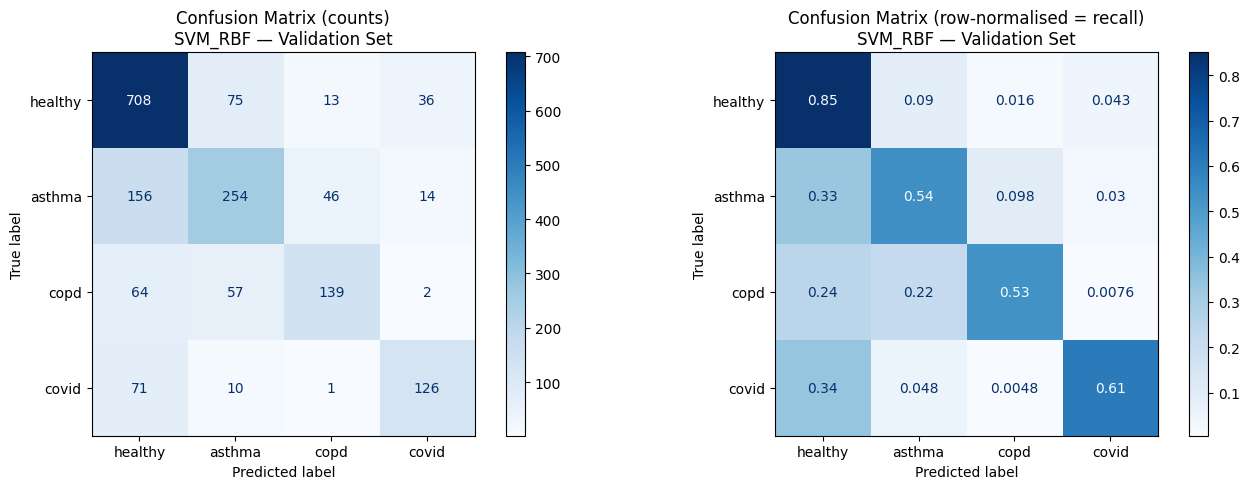

  Saved → confusion_matrix_val.png

-----------------------------------------------------------------
16d : Per-class ROC Curves (One-vs-Rest)
-----------------------------------------------------------------


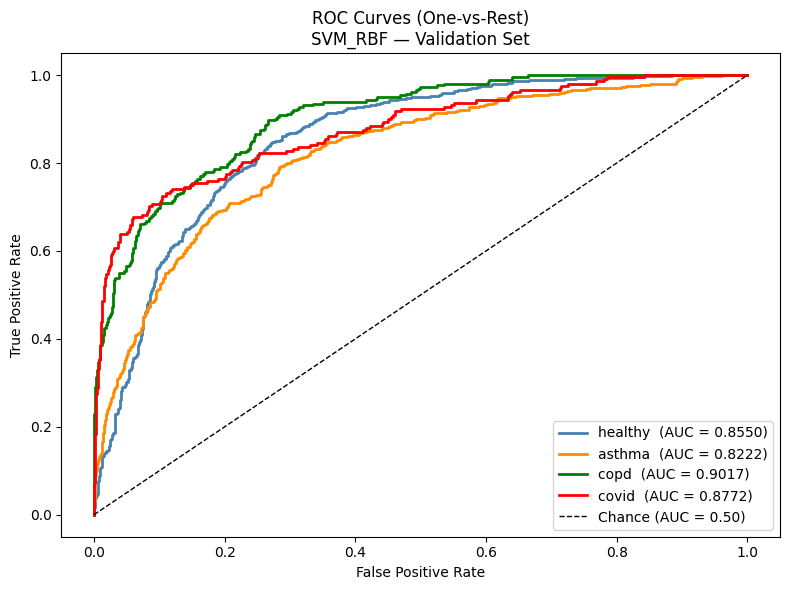

  Saved → roc_curves_val.png

-----------------------------------------------------------------
16e : Per-class Metrics Summary Table
-----------------------------------------------------------------
         Precision  Recall      F1  ROC-AUC  Support
Class                                               
healthy     0.7087  0.8510  0.7733   0.8550      832
asthma      0.6414  0.5404  0.5866   0.8222      470
copd        0.6985  0.5305  0.6030   0.9017      262
covid       0.7079  0.6058  0.6528   0.8772      208

STEP 16 COMPLETE — Validation Evaluation Summary
  Model           : SVM_RBF
  Accuracy        : 0.6924
  Cohen's Kappa   : 0.5251
  ROC-AUC (macro) : 0.8640
  Log Loss        : 0.9652

  Files saved:
    confusion_matrix_val.png
    roc_curves_val.png


In [35]:
# =============================================================================
# STEP 13 — VALIDATION SET EVALUATION (BEST MODEL)
# =============================================================================
# Everything above was on training data only. This step gives the true
# unbiased picture of how the best tuned model generalises to unseen data.
#
# Metrics reported:
#   • Classification report  — precision, recall, F1 per class + weighted avg
#   • Confusion matrix       — where the model confuses classes
#   • Overall accuracy       — % of all predictions correct
#   • Cohen's Kappa          — accuracy corrected for chance agreement
#   • ROC-AUC (macro OvR)    — discrimination ability across all 4 classes
#   • Log Loss               — confidence calibration quality (lower = better)
# =============================================================================


print("=" * 65)
print("STEP 16 : Validation set evaluation — best model")
print(f"          Model : {best_model_name}")
print("=" * 65)

# --- Load validation set ---
df_val = pd.read_csv(r"E:\first_iterations\val_66.csv")           
df_val = df_val.rename(columns={"disease_y": "disease"})

X_val = df_val.drop(columns=["disease"]).copy()
y_val_str = df_val["disease"].copy()

# Encode validation labels using the same mapping as training
label_map     = {"healthy": 0, "asthma": 1, "copd": 2, "covid": 3}
inv_label_map = {0: "healthy", 1: "asthma", 2: "copd", 3: "covid"}
class_names   = ["healthy", "asthma", "copd", "covid"]

y_val = y_val_str.map(label_map)

print(f"\n Validation set shape : {X_val.shape}")
print(f" Class distribution:")
print(y_val_str.value_counts().to_string())
print()

# --- Predictions ---
y_pred       = final_model.predict(X_val)           # integer predictions
y_pred_proba = final_model.predict_proba(X_val)     # shape (n_samples, 4)
                                                    # needed for AUC + log loss

# =============================================================================
# 13a — Classification Report (per-class precision / recall / F1)
# =============================================================================
print("-" * 65)
print("16a : Classification Report")
print("-" * 65)
print(classification_report(
    y_val, y_pred,
    target_names=class_names,
    digits=4,
))

# =============================================================================
# 13b — Scalar summary metrics
# =============================================================================
accuracy = accuracy_score(y_val, y_pred)
kappa    = cohen_kappa_score(y_val, y_pred)
roc_auc  = roc_auc_score(
    y_val, y_pred_proba,
    multi_class="ovr",   # One-vs-Rest: computes AUC for each class vs all others
    average="macro",     # unweighted mean across the 4 classes
)
logloss  = log_loss(y_val, y_pred_proba)

print("-" * 65)
print("16b : Scalar Metrics")
print("-" * 65)
print(f"  Accuracy        : {accuracy:.4f}")
print(f"  Cohen's Kappa   : {kappa:.4f}   (0=chance, 1=perfect, >0.8=strong)")
print(f"  ROC-AUC (macro) : {roc_auc:.4f}  (chance=0.5, perfect=1.0)")
print(f"  Log Loss        : {logloss:.4f}  (lower is better; 0=perfect)")
print()

# =============================================================================
# 13c — Confusion Matrix heatmap
# =============================================================================
print("-" * 65)
print("16c : Confusion Matrix")
print("-" * 65)

cm = confusion_matrix(y_val, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Raw counts ---
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], colorbar=True, cmap="Blues"
)
axes[0].set_title(f"Confusion Matrix (counts)\n{best_model_name} — Validation Set")

# --- Row-normalised (recall per class) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
    ax=axes[1], colorbar=True, cmap="Blues"
)
axes[1].set_title(f"Confusion Matrix (row-normalised = recall)\n{best_model_name} — Validation Set")

plt.tight_layout()
plt.savefig(r"E:\first_iterations\checkin-2\xgboost + others\confusion_matrix_val.png", dpi=150)
plt.show()
print("  Saved → confusion_matrix_val.png")
print()

# =============================================================================
# 13d — Per-class ROC curves (One-vs-Rest)
# =============================================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

print("-" * 65)
print("16d : Per-class ROC Curves (One-vs-Rest)")
print("-" * 65)

# Binarize ground truth: shape (n_samples, 4), one column per class
y_val_bin = label_binarize(y_val, classes=[0, 1, 2, 3])

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue", "darkorange", "green", "red"]

for i, (cls_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_pred_proba[:, i])
    cls_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{cls_name}  (AUC = {cls_auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance (AUC = 0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves (One-vs-Rest)\n{best_model_name} — Validation Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(r"E:\first_iterations\checkin-2\xgboost + others\roc_curves_val.png", dpi=150)
plt.show()
print("  Saved → roc_curves_val.png")
print()

# =============================================================================
# 13e — Per-class metrics summary table
# =============================================================================
print("-" * 65)
print("16e : Per-class Metrics Summary Table")
print("-" * 65)

from sklearn.metrics import precision_score, recall_score, f1_score

per_class_rows = []
for i, cls_name in enumerate(class_names):
    y_val_bin_i  = (y_val == i).astype(int)
    y_pred_bin_i = (y_pred == i).astype(int)
    cls_auc      = roc_auc_score(y_val_bin_i, y_pred_proba[:, i])

    per_class_rows.append({
        "Class"    : cls_name,
        "Precision": round(precision_score(y_val_bin_i, y_pred_bin_i), 4),
        "Recall"   : round(recall_score   (y_val_bin_i, y_pred_bin_i), 4),
        "F1"       : round(f1_score       (y_val_bin_i, y_pred_bin_i), 4),
        "ROC-AUC"  : round(cls_auc, 4),
        "Support"  : int(y_val_bin_i.sum()),
    })

per_class_df = pd.DataFrame(per_class_rows).set_index("Class")
print(per_class_df.to_string())
print()

# =============================================================================
# 13f — Final verdict
# =============================================================================
print("=" * 65)
print("STEP 16 COMPLETE — Validation Evaluation Summary")
print("=" * 65)
print(f"  Model           : {best_model_name}")
print(f"  Accuracy        : {accuracy:.4f}")
print(f"  Cohen's Kappa   : {kappa:.4f}")
print(f"  ROC-AUC (macro) : {roc_auc:.4f}")
print(f"  Log Loss        : {logloss:.4f}")
print()
print("  Files saved:")
print("    confusion_matrix_val.png")
print("    roc_curves_val.png")
print("=" * 65)

In [36]:
print("=" * 65)
print("STEP 14 : Saving the trained model to disk")
print("=" * 65)
 
MODEL_PATH = r"E:\first_iterations\checkin-2\xgboost + others\svm_with_val.pkl"
 
joblib.dump(final_model, MODEL_PATH)
 
print(f"  Trained pipeline  → {MODEL_PATH}")
print()
print(" To use later on your test set:")
print("   import joblib, numpy as np")
print(f"   model  = joblib.load('{MODEL_PATH}')")
print("   label_map = {0: 'healthy', 1: 'asthma', 2: 'copd', 3: 'covid'}")
print("   preds  = [label_map[p] for p in model.predict(X_test)]")

print()
print("=" * 65)
print("TRAINING PIPELINE COMPLETE")
print("=" * 65)

STEP 14 : Saving the trained model to disk
  Trained pipeline  → E:\first_iterations\checkin-2\xgboost + others\svm_with_val.pkl

 To use later on your test set:
   import joblib, numpy as np
   model  = joblib.load('E:\first_iterations\checkin-2\xgboost + others\svm_with_val.pkl')
   label_map = {0: 'healthy', 1: 'asthma', 2: 'copd', 3: 'covid'}
   preds  = [label_map[p] for p in model.predict(X_test)]

TRAINING PIPELINE COMPLETE


In [ ]:
clf_step = final_model.named_steps["clf"]

tree0 = clf_step.predictors_[0][0]
print(tree0.nodes.dtype.names)

NameError: name 'clf_step' is not defined

STEP 15 : Extracting learned feature ranges per class
  Features entering the classifier : 45
  Classes                          : ['healthy', 'asthma', 'copd', 'covid']
  Total trees to mine              : 684

  Tree mining complete.

-----------------------------------------------------------------
17d : Learned split ranges per class (original feature units)
      'Min/Max Threshold' = the boundary values the model split on
      'Split Count'       = how often this feature was used (importance)
-----------------------------------------------------------------

  ── HEALTHY ──
     Feature  Min Threshold  Median Threshold  Max Threshold  Split Count
         age        18.5000           42.5000        79.5000          369
 mfcc_8_mean       -41.2687          -10.8802        18.5334          218
 mfcc_4_mean       -25.6864           35.9622       106.0701          211
mfcc_10_mean       -41.4085           -9.0445        15.9579          186
 mfcc_3_mean      -133.3608          -57.6

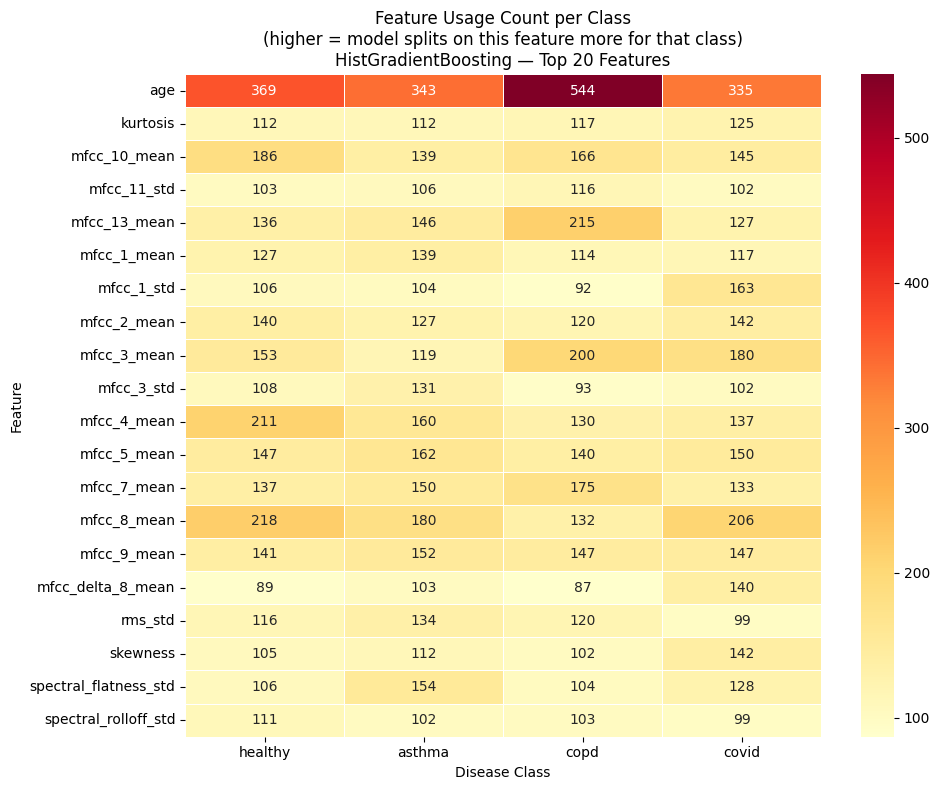

  Heatmap saved → feature_class_heatmap.png

STEP 15 COMPLETE


In [ ]:
# =============================================================================
# STEP 15 — EXTRACT LEARNED FEATURE RANGES PER CLASS
# =============================================================================
# HistGradientBoosting internally builds 'predictors_' — a list of trees.
# Structure: predictors_[boosting_round][class_index]
# For 4 classes and 300 rounds → 1,200 trees total.
#
# We mine all trees to extract, for each feature:
#   • all the split thresholds the model actually used
#   • which class benefited from each split (via leaf values)
# Then we summarise as "effective ranges" per feature per class.
# =============================================================================

# The ranges show where the model draws its decision boundaries, 
# not a clean "asthma lives between X and Y." 
# A boosted tree works by combining hundreds of weak splits, 
# so the same feature may appear with a low threshold in some trees and a high threshold in others —
# the Median Threshold column is your best single-number summary of 
# where the model "draws the line" for each feature per class. 
# The Split Count tells you how much the model relied on that feature for that class —
# - treat it like a per-class feature importance.


print("=" * 65)
print("STEP 15 : Extracting learned feature ranges per class")
print("=" * 65)

clf_step     = final_model.named_steps["clf"]
featsel_step = final_model.named_steps["featsel"]

# --- Reconstruct the names of features that survived into the classifier ---
all_names_after_prep = num_cols + cat_cols

var_mask       = featsel_step.named_steps["var_filter"].get_support()
names_after_var = [n for n, m in zip(all_names_after_prep, var_mask) if m]

kbest_mask     = featsel_step.named_steps["kbest"].get_support()
selected_names = [n for n, m in zip(names_after_var, kbest_mask) if m]

n_features = len(selected_names)
# Manual mapping (since le was removed)

class_label_map = {
    0: "healthy",
    1: "asthma",
    2: "copd",
    3: "covid"
}

class_indices = list(clf_step.classes_)

class_names = [
    class_label_map[i]
    for i in class_indices
]

n_classes = len(class_names)

print(f"  Features entering the classifier : {n_features}")
print(f"  Classes                          : {class_names}")
print(f"  Total trees to mine              : "
      f"{len(clf_step._predictors) * n_classes}")
print()

# =============================================================================
# 15a — Mine every tree for split thresholds + leaf values
# =============================================================================
# For each tree we collect:
#   feature_idx  → which feature was split on
#   threshold    → the split value (in SCALED space)
#   leaf_value   → the score boost for the associated class
#                  positive leaf value = model is pushing toward that class
#
# Note: thresholds are in StandardScaler space (mean=0, std=1).
# We will INVERSE TRANSFORM them back to original units afterward.

# Structure:
# thresholds_per_class[class_idx][feature_idx] = [list of thresholds]
# leafvals_per_class  [class_idx][feature_idx] = [list of leaf values at splits]

thresholds_per_class = {c: {f: [] for f in range(n_features)}
                        for c in range(n_classes)}

for round_idx, round_trees in enumerate(clf_step._predictors):
    for class_idx, tree in enumerate(round_trees):
        # tree.nodes is a structured numpy array with fields:
        #   'feature_idx', 'threshold', 'is_leaf', 'left', 'right',
        #   'value' (leaf prediction score)
        nodes = tree.nodes
        for node in nodes:
            if not node["is_leaf"]:
                feat_idx  = node["feature_idx"]
                threshold = node["num_threshold"]
                if feat_idx < n_features:   # guard against OOB
                    thresholds_per_class[class_idx][feat_idx].append(threshold)

print("  Tree mining complete.")
print()

# =============================================================================
# 15b — Inverse transform thresholds back to original feature space
# =============================================================================
# StandardScaler stores mean_ and scale_ for each feature.
# original_value = scaled_value * scale + mean
#
# We only inverse-transform NUMERIC features (not categoricals).
# Cat features (gender, smoker, cold_present) are OrdinalEncoded 0/1/2
# and were not scaled, so their thresholds are already in encoded units.

scaler = final_model.named_steps["prep"] \
                    .named_transformers_["num"] \
                    .named_steps["scaler"]

# scaler was fit on num_cols (69 features).
# selected_names may include cat_cols at the end — handle separately.
num_feature_set = set(num_cols)

def inverse_scale(feat_name, scaled_val):
    """Convert a scaled threshold back to original units."""
    if feat_name in num_feature_set:
        # find index of this feature in num_cols
        idx = num_cols.index(feat_name)
        return scaled_val * scaler.scale_[idx] + scaler.mean_[idx]
    else:
        # categorical — already in ordinal encoded space (0, 1, 2 etc.)
        return scaled_val

# =============================================================================
# 15c — Summarise: for each feature × class, compute the effective range
# =============================================================================
# "Effective range" = the span of thresholds the model actually split on
# for that feature when boosting toward that class.
# min(thresholds) → lower bound the model cares about
# max(thresholds) → upper bound the model cares about
# count           → how many times this feature was used (importance proxy)

records = []

for class_idx, cls_name in enumerate(class_names):
    for feat_idx, feat_name in enumerate(selected_names):
        raw_thresholds = thresholds_per_class[class_idx][feat_idx]
        if len(raw_thresholds) == 0:
            continue   # feature never used for this class

        orig_thresholds = [inverse_scale(feat_name, t) for t in raw_thresholds]

        records.append({
            "Class"      : cls_name,
            "Feature"    : feat_name,
            "Min Threshold": round(min(orig_thresholds), 4),
            "Max Threshold": round(max(orig_thresholds), 4),
            "Median Threshold": round(float(np.median(orig_thresholds)), 4),
            "Split Count": len(orig_thresholds),   # higher = more important
        })

ranges_df = (
    pd.DataFrame(records)
    .sort_values(["Class", "Split Count"], ascending=[True, False])
    .reset_index(drop=True)
)

# =============================================================================
# 15d — Print per-class top features with their ranges
# =============================================================================
print("-" * 65)
print("17d : Learned split ranges per class (original feature units)")
print("      'Min/Max Threshold' = the boundary values the model split on")
print("      'Split Count'       = how often this feature was used (importance)")
print("-" * 65)

for cls_name in class_names:
    cls_df = (
        ranges_df[ranges_df["Class"] == cls_name]
        .head(15)   # top 15 most-used features per class
    )
    print(f"\n  ── {cls_name.upper()} ──")
    print(cls_df[["Feature", "Min Threshold", "Median Threshold",
                  "Max Threshold", "Split Count"]].to_string(index=False))

print()

# =============================================================================
# 15e — Save full table to CSV
# =============================================================================
ranges_df.to_csv(r"E:\first_iterations\checkin-2\xgboost + others\learned_feature_ranges.csv", index=False)
print("  Full table saved → learned_feature_ranges.csv")
print()

# ============================================================================
# 15f — Heatmap: Split Count per feature × class (top 20 features overall)
# =============================================================================
top_features = (
    ranges_df.groupby("Feature")["Split Count"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index.tolist()
)

pivot = (
    ranges_df[ranges_df["Feature"].isin(top_features)]
    .pivot_table(index="Feature", columns="Class",
                 values="Split Count", fill_value=0)
    [class_names]   # keep class column order consistent
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pivot, annot=True, fmt=".0f", cmap="YlOrRd",
    linewidths=0.5, ax=ax
)
ax.set_title(f"Feature Usage Count per Class\n"
             f"(higher = model splits on this feature more for that class)\n"
             f"{best_model_name} — Top 20 Features")
ax.set_xlabel("Disease Class")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(r"E:\first_iterations\checkin-2\feature_class_heatmap.png", dpi=150)
plt.show()
print("  Heatmap saved → feature_class_heatmap.png")

print()
print("=" * 65)
print("STEP 15 COMPLETE")
print("=" * 65)

STEP 16 : Test set evaluation — best model
          Model : HistGradientBoosting

 Test set shape : (1626, 73)
 Class distribution:
disease
healthy    840
asthma     346
copd       245
covid      195

-----------------------------------------------------------------
16a : Classification Report
-----------------------------------------------------------------
              precision    recall  f1-score   support

     healthy     0.7413    0.7571    0.7491       840
      asthma     0.4485    0.4653    0.4567       346
        copd     0.6193    0.5510    0.5832       245
       covid     0.5654    0.5538    0.5596       195

    accuracy                         0.6396      1626
   macro avg     0.5936    0.5818    0.5871      1626
weighted avg     0.6395    0.6396    0.6392      1626

-----------------------------------------------------------------
16b : Scalar Metrics
-----------------------------------------------------------------
  Accuracy        : 0.6396
  Cohen's Kappa   : 0.4

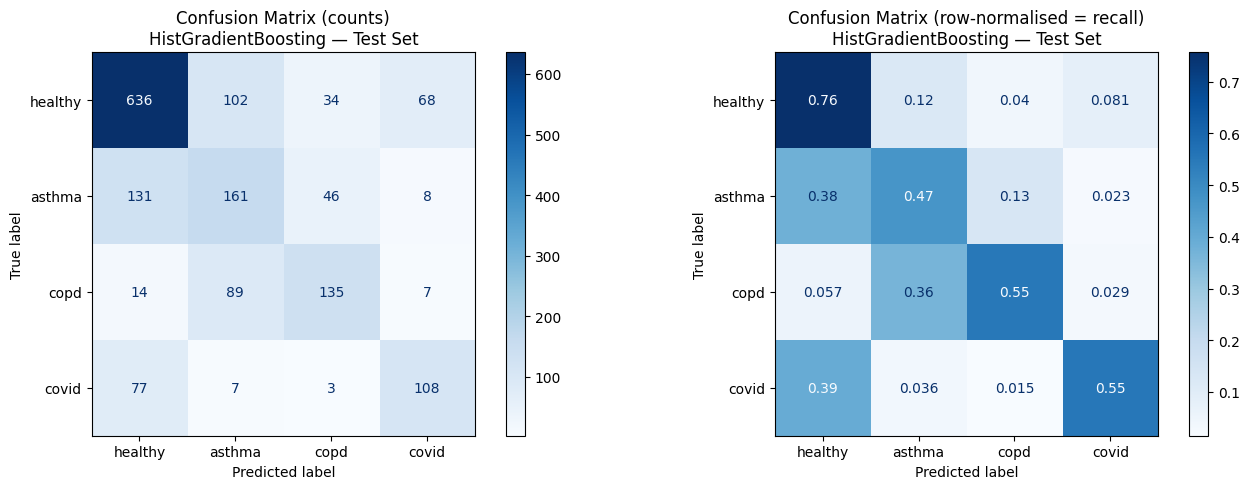

  Saved → confusion_matrix_test.png

-----------------------------------------------------------------
16d : Per-class ROC Curves (One-vs-Rest)
-----------------------------------------------------------------


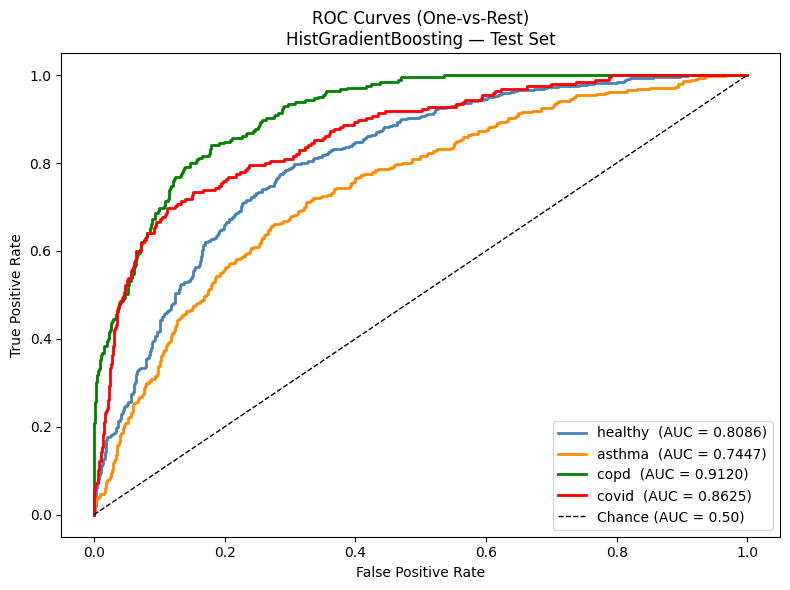

  Saved → roc_curves_test.png

-----------------------------------------------------------------
16e : Per-class Metrics Summary Table
-----------------------------------------------------------------
         Precision  Recall      F1  ROC-AUC  Support
Class                                               
healthy     0.7413  0.7571  0.7491   0.8086      840
asthma      0.4485  0.4653  0.4567   0.7447      346
copd        0.6193  0.5510  0.5832   0.9120      245
covid       0.5654  0.5538  0.5596   0.8625      195

STEP 16 COMPLETE — Test Evaluation Summary
  Model           : HistGradientBoosting
  Accuracy        : 0.6396
  Cohen's Kappa   : 0.4422
  ROC-AUC (macro) : 0.8320
  Log Loss        : 1.2223

  Files saved:
    confusion_matrix_test.png
    roc_curves_test.png


In [ ]:
# =============================================================================
# STEP 16 — TEST SET EVALUATION
# =============================================================================
# Everything above was on training data only. This step gives the true
# unbiased picture of how the best tuned model generalises to unseen data.
#
# Metrics reported:
#   • Classification report  — precision, recall, F1 per class + weighted avg
#   • Confusion matrix       — where the model confuses classes
#   • Overall accuracy       — % of all predictions correct
#   • Cohen's Kappa          — accuracy corrected for chance agreement
#   • ROC-AUC (macro OvR)    — discrimination ability across all 4 classes
#   • Log Loss               — confidence calibration quality (lower = better)
# =============================================================================


print("=" * 65)
print("STEP 16 : Test set evaluation — best model")
print(f"          Model : {best_model_name}")
print("=" * 65)

# --- Load test set ---
df_test = pd.read_csv(r"E:\first_iterations\test_66.csv")           
df_test = df_test.rename(columns={"disease_y": "disease"})

X_test = df_test.drop(columns=["disease"]).copy()
y_test_str = df_test["disease"].copy()

# Encode test labels using the same mapping as training
label_map     = {"healthy": 0, "asthma": 1, "copd": 2, "covid": 3}
inv_label_map = {0: "healthy", 1: "asthma", 2: "copd", 3: "covid"}
class_names   = ["healthy", "asthma", "copd", "covid"]

y_test = y_test_str.map(label_map)

print(f"\n Test set shape : {X_test.shape}")
print(f" Class distribution:")
print(y_test_str.value_counts().to_string())
print()

# --- Predictions ---
y_pred       = final_model.predict(X_test)           # integer predictions
y_pred_proba = final_model.predict_proba(X_test)     # shape (n_samples, 4)
                                                    # needed for AUC + log loss

# =============================================================================
# 16a — Classification Report (per-class precision / recall / F1)
# =============================================================================
print("-" * 65)
print("16a : Classification Report")
print("-" * 65)
print(classification_report(
    y_test, y_pred,
    target_names=class_names,
    digits=4,
))

# =============================================================================
# 16b — Scalar summary metrics
# =============================================================================
accuracy = accuracy_score(y_test, y_pred)
kappa    = cohen_kappa_score(y_test, y_pred)
roc_auc  = roc_auc_score(
    y_test, y_pred_proba,
    multi_class="ovr",   # One-vs-Rest: computes AUC for each class vs all others
    average="macro",     # unweighted mean across the 4 classes
)
logloss  = log_loss(y_test, y_pred_proba)

print("-" * 65)
print("16b : Scalar Metrics")
print("-" * 65)
print(f"  Accuracy        : {accuracy:.4f}")
print(f"  Cohen's Kappa   : {kappa:.4f}   (0=chance, 1=perfect, >0.8=strong)")
print(f"  ROC-AUC (macro) : {roc_auc:.4f}  (chance=0.5, perfect=1.0)")
print(f"  Log Loss        : {logloss:.4f}  (lower is better; 0=perfect)")
print()

# =============================================================================
# 16c — Confusion Matrix heatmap
# =============================================================================
print("-" * 65)
print("16c : Confusion Matrix")
print("-" * 65)

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Raw counts ---
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], colorbar=True, cmap="Blues"
)
axes[0].set_title(f"Confusion Matrix (counts)\n{best_model_name} — Test Set")

# --- Row-normalised (recall per class) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
    ax=axes[1], colorbar=True, cmap="Blues"
)
axes[1].set_title(f"Confusion Matrix (row-normalised = recall)\n{best_model_name} — Test Set")

plt.tight_layout()
plt.savefig(r"E:\first_iterations\checkin-2\confusion_matrix_test.png", dpi=150)
plt.show()
print("  Saved → confusion_matrix_test.png")
print()

# =============================================================================
# 16d — Per-class ROC curves (One-vs-Rest)
# =============================================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

print("-" * 65)
print("16d : Per-class ROC Curves (One-vs-Rest)")
print("-" * 65)

# Binarize ground truth: shape (n_samples, 4), one column per class
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue", "darkorange", "green", "red"]

for i, (cls_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    cls_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{cls_name}  (AUC = {cls_auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance (AUC = 0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves (One-vs-Rest)\n{best_model_name} — Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(r"E:\first_iterations\checkin-2\xgboost + others\roc_curves_test.png", dpi=150)
plt.show()
print("  Saved → roc_curves_test.png")
print()

# =============================================================================
# 16e — Per-class metrics summary table
# =============================================================================
print("-" * 65)
print("16e : Per-class Metrics Summary Table")
print("-" * 65)

from sklearn.metrics import precision_score, recall_score, f1_score

per_class_rows = []
for i, cls_name in enumerate(class_names):
    y_test_bin_i  = (y_test == i).astype(int)
    y_pred_bin_i = (y_pred == i).astype(int)
    cls_auc      = roc_auc_score(y_test_bin_i, y_pred_proba[:, i])

    per_class_rows.append({
        "Class"    : cls_name,
        "Precision": round(precision_score(y_test_bin_i, y_pred_bin_i), 4),
        "Recall"   : round(recall_score   (y_test_bin_i, y_pred_bin_i), 4),
        "F1"       : round(f1_score       (y_test_bin_i, y_pred_bin_i), 4),
        "ROC-AUC"  : round(cls_auc, 4),
        "Support"  : int(y_test_bin_i.sum()),
    })

per_class_df = pd.DataFrame(per_class_rows).set_index("Class")
print(per_class_df.to_string())
print()

# =============================================================================
# 16f — Final verdict
# =============================================================================
print("=" * 65)
print("STEP 16 COMPLETE — Test Evaluation Summary")
print("=" * 65)
print(f"  Model           : {best_model_name}")
print(f"  Accuracy        : {accuracy:.4f}")
print(f"  Cohen's Kappa   : {kappa:.4f}")
print(f"  ROC-AUC (macro) : {roc_auc:.4f}")
print(f"  Log Loss        : {logloss:.4f}")
print()
print("  Files saved:")
print("    confusion_matrix_test.png")
print("    roc_curves_test.png")
print("=" * 65)